In [12]:
from langgraph.graph import StateGraph, START, END
from  langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Literal, Annotated
from langgraph.prebuilt import ToolNode

load_dotenv()

True

In [9]:

from langchain_core.tools import tool
import requests

# =============================================================================
# Weather Tools
# =============================================================================

@tool
def get_weather(location:str) -> str:
    """Get current weather for a location.
    
    Use for queries about weather, temperature, or conditions in any city.
    Examples: "weather in Paris", "temperature in Tokyo", "is it raining in London"
    
    Args:
        location: City name (e.g., "New York", "London", "Tokyo")
        
    Returns:
        Current weather information including temperature and conditions.
    """

    url = f"https://wttr.in/{location}?format=j1"
    response = requests.get(url, timeout=10)

    response.raise_for_status()
    data = response.json()

    return data



# =============================================================================
# Math Tools
# =============================================================================
@tool
def calculate(expression: str) -> str:
    """Calculate a mathematical expression.
    
    USE THIS TOOL FOR:
    - Any mathematical calculations or arithmetic operations
    - Queries involving numbers and operators (+, -, *, /, **, %)
    - Questions asking to compute, calculate, or solve math problems
    - Evaluating mathematical expressions
    
    EXAMPLE QUERIES:
    - "What is 2 + 2?"
    - "Calculate 15 times 7"
    - "Solve 100 / 4"
    - "What's 5 to the power of 3?"
    - "Compute 45 * 12 + 30"
    
    DO NOT USE FOR:
    - Word problems without explicit expressions (extract the math first)
    - Questions about mathematical concepts or theory

    Args:
        expression: Math expression like "2 + 2" or "15 * 7" (use standard Python operators)
    """

    try:
        result = eval(expression)
        print(f"[TOOL] calculate ('{expression}') -> '{result}'")
    except Exception as e:
        print(f"Exception has occured with error: {e}")
        return f"Exception has occured with error: {e}"

    return result


all_tools = [get_weather, calculate]

In [2]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [7]:
import operator


In [8]:
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

In [10]:
def agent_node(state: AgentState):

    llm_with_tools = llm.bind_tools(all_tools)

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    if hasattr(response, 'tool_calls') and response.tool_calls:
        for tc in response.tool_calls:
            print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
    else:
        print(f"[AGENT] Responding...")


    return {'messages': [response]}

In [11]:
def should_continue(state: AgentState):
    last = state['messages'][-1]
    
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return "tools"
    else:
        return END

In [13]:
def create_agent():

    builder = StateGraph(AgentState)

    builder.add_node("agent", agent_node)
    builder.add_node("tools", ToolNode(all_tools))


    builder.add_edge(START, "agent")
    builder.add_conditional_edges("agent", should_continue, ["tools", END])

    builder.add_edge("tools", "agent")

    graph = builder.compile()

    return graph

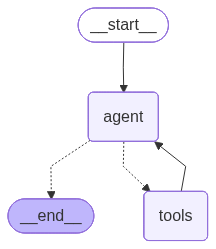

In [14]:
agent = create_agent()
agent

In [15]:
query = "What is the current weather in Mumbai?"

result = agent.invoke({'messages': [HumanMessage(query)]})

[AGENT] called Tool get_weather with args {'location': 'Mumbai'}
[AGENT] Responding...


In [16]:
result

{'messages': [HumanMessage(content='What is the current weather in Mumbai?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 299, 'total_tokens': 313, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_86eb24cbce', 'id': 'chatcmpl-DyCUZNAivyfaZSrL3v0UO47pMAaac', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f3164-1503-72d0-822d-e7ed01ce6164-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Mumbai'}, 'id': 'call_znljFgYRYbwJjcUU9GTReEJI', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 299, 'output_tokens': 14, 'total_token